In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/stzh.zwn_meldungen_p.csv") #importing the dataset and calling it "df"
df.head()


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14T15:16:15,2013-04-04T07:25:05,2013-04-12T07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14T15:17:57,2013-03-26T14:05:05,2013-04-12T08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15T09:14:16,2013-03-15T09:55:05,2013-04-12T08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15T09:17:15,2013-03-20T10:05:05,2013-04-12T08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15T10:36:53,2013-04-22T18:25:05,2013-04-23T13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


Now I have the data, I want to check to find where the types of incidents are listed(graffiti, vandalism, etc.), so:

In [3]:
df["service_name"].unique() #unique values in service_name

<ArrowStringArray>
[   'Strasse/Trottoir/Platz',       'Abfall/Sammelstelle',
   'Grünflächen/Spielplätze',         'Beleuchtung/Uhren',
                  'Graffiti', 'Signalisation/Lichtsignal',
         'Brunnen/Hydranten',                    'VBZ/ÖV',
                 'Allgemein',                'Schädlinge']
Length: 10, dtype: str

In [9]:
df["geometry"].head() #spatial geometry of point of each incident


0    POINT (2678968 1247548)
1    POINT (2680746 1249916)
2    POINT (2684605 1251431)
3    POINT (2681754 1250376)
4    POINT (2683094 1247762)
Name: geometry, dtype: str

Each incident has a geographical point location, likely using Swiss projection coordinates(e.g. Swiss CRS EPSG: 2056 projection). Also "dtype:str" signals that the data is stored in the form of text strings, thus will need to be transformed into spatial objects. This means transforming the dataframe into a GeoDataFrame, so that these text strings can be converted to real geographical locations and can be mapped or spatially joined.

In [4]:
df["service_name"].value_counts() #number of incidents for each event

service_name
Abfall/Sammelstelle          27445
Signalisation/Lichtsignal    10984
Strasse/Trottoir/Platz        9874
Grünflächen/Spielplätze       7254
Beleuchtung/Uhren             5414
Allgemein                     3977
Graffiti                      3780
VBZ/ÖV                        1886
Brunnen/Hydranten             1295
Schädlinge                     895
Name: count, dtype: int64

For this analysis, relevant columns are "requested_datetime", "service_name","geometry", and perhaps "title" and "status"

In [11]:
cleaned_df = df[["requested_datetime", "service_name","status","title","geometry"]] #creating the new dataset with
#relevant columns
cleaned_df.head()

,requested_datetime,service_name,status,title,geometry
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548)
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916)
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431)
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376)
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762)


Now we have the dataframe with the relevant columns, we can convert the text strings into geometry objects using GeoPandas and Well-Known Text from Shapely, so:

In [12]:
import geopandas as gpd #for working with spatial data
from shapely import wkt #for converting text strings into spatial objects

Now we convert the geometry column values into spatial data, so:

In [14]:
cleaned_df["geometry"] = cleaned_df["geometry"].apply(wkt.loads) #this converts text strings into Shapely Points

TypeError: Expected bytes or string, got Point

The error shows how it was expected to be working with bytes or strings but it actually was Point data in the geometry column, signalling that the dataset is already close to a GeoDataFrame. Now we can create the GeoDataFrame, so:

In [20]:
zurich_gdf = gpd.GeoDataFrame(cleaned_df, geometry="geometry", crs="EPSG:2056") # added CRS so it is usable in other systems(according to error)

type(zurich_gdf)#verify that the type of the dataset is a GeoDataFrame

geopandas.geodataframe.GeoDataFrame

<Axes: >

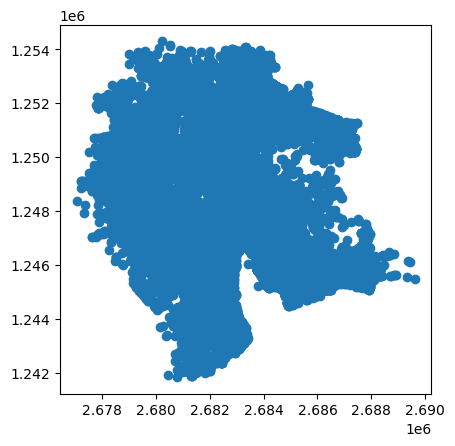

In [21]:
zurich_gdf.plot()#the data is working when we map it too

In [22]:
zurich_gdf.to_file("../data/processed/zurich_gdf.gpkg") #save the data to the folder to work with later